# 04 — Inter-biometric VAR(3) residual correlations and variance decomposition (S9)

Reproduces **Figure S9**: residual correlation matrix and forecast-error
variance decomposition (FEVD) of a VAR(3) model fit on per-user normalised
biometric time-series (RHR, HRV, RR, skin temp, blood O₂).

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from menstrual_cycle_analysis import (
    Biometrics_VAR,
    PhysioMethods,
    load_paper_data,
)

np.random.seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

## Load data and initialise PhysioMethods

In [2]:
day_df, CBM = load_paper_data()
PM = PhysioMethods(cbm=CBM)
PM.get_reference_table()
PM.process_physio_data(overwrite=True)
print(f"users:       {len(PM.users):,}")
print(f"data days:   {len(PM.data):,}")
print(f"biometrics:  {PM.CORE_BIOMETRICS}")

Getting cycle bounds (optimized)


  0%|          | 0/2596 [00:00<?, ?it/s]

  2%|▏         | 51/2596 [00:00<00:05, 505.08it/s]

  6%|▌         | 144/2596 [00:00<00:03, 752.81it/s]

  9%|▉         | 241/2596 [00:00<00:02, 850.36it/s]

...

 94%|█████████▎| 2433/2596 [00:02<00:00, 1038.87it/s]

 98%|█████████▊| 2538/2596 [00:02<00:00, 1024.17it/s]

100%|██████████| 2596/2596 [00:02<00:00, 962.24it/s] 

Converting to DataFrame...


users:       2,596
data days:   1,298,555
biometrics:  ['RHR', 'HRV', 'RR', 'skin_temp', 'blood_oxygen']


## Fit VAR(3) on per-user normalised biometrics

`Biometrics_VAR.prepare_data` filters each user's biometrics with the VAR
preset (2nd-order causal Butterworth, w=[1/90, 1/3]), normalises by the user's
mean, drops NaN rows, and concatenates across users. Then `fit_model` fits a
VAR(3) with constant + linear trend.

In [3]:
BV = Biometrics_VAR(pm=PM)
BV.prepare_data()
BV.fit_model(lag_order=3)
BV.data.shape

  0%|          | 0/2596 [00:00<?, ?it/s]

  0%|          | 10/2596 [00:00<00:26, 97.45it/s]

  1%|          | 23/2596 [00:00<00:22, 113.87it/s]

  1%|▏         | 36/2596 [00:00<00:21, 117.73it/s]

  2%|▏         | 48/2596 [00:00<00:26, 95.63it/s] 

...

 99%|█████████▉| 2581/2596 [00:23<00:00, 117.19it/s]

100%|█████████▉| 2594/2596 [00:23<00:00, 119.33it/s]

100%|██████████| 2596/2596 [00:23<00:00, 111.80it/s]


/Users/alex/miniforge3/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


(914440, 5)

In [4]:
BV.data.head()

,f_RHR,f_HRV,f_RR,f_skin_temp,f_blood_oxygen
120,0.196343,4.844778,0.839015,-1.029028,0.040253
121,1.243254,-4.946672,-0.094680,-1.726488,-0.431048
122,3.764729,-13.651552,0.727506,-0.569940,-1.233977
123,3.932703,-13.604293,1.156530,-0.642040,-0.949447
124,-1.230286,6.074875,-0.073410,0.428551,-0.580301


## Figure S9 — residual correlations + variance decomposition

In [5]:
A = BV.get_residual_corr_matrix()
A.round(2)

,f_RHR,f_HRV,f_RR,f_skin_temp,f_blood_oxygen
f_RHR,1.00,-0.71,0.41,0.12,-0.05
f_HRV,-0.71,1.00,-0.25,-0.11,0.02
f_RR,0.41,-0.25,1.00,0.07,-0.05
f_skin_temp,0.12,-0.11,0.07,1.00,0.00
f_blood_oxygen,-0.05,0.02,-0.05,0.00,1.00


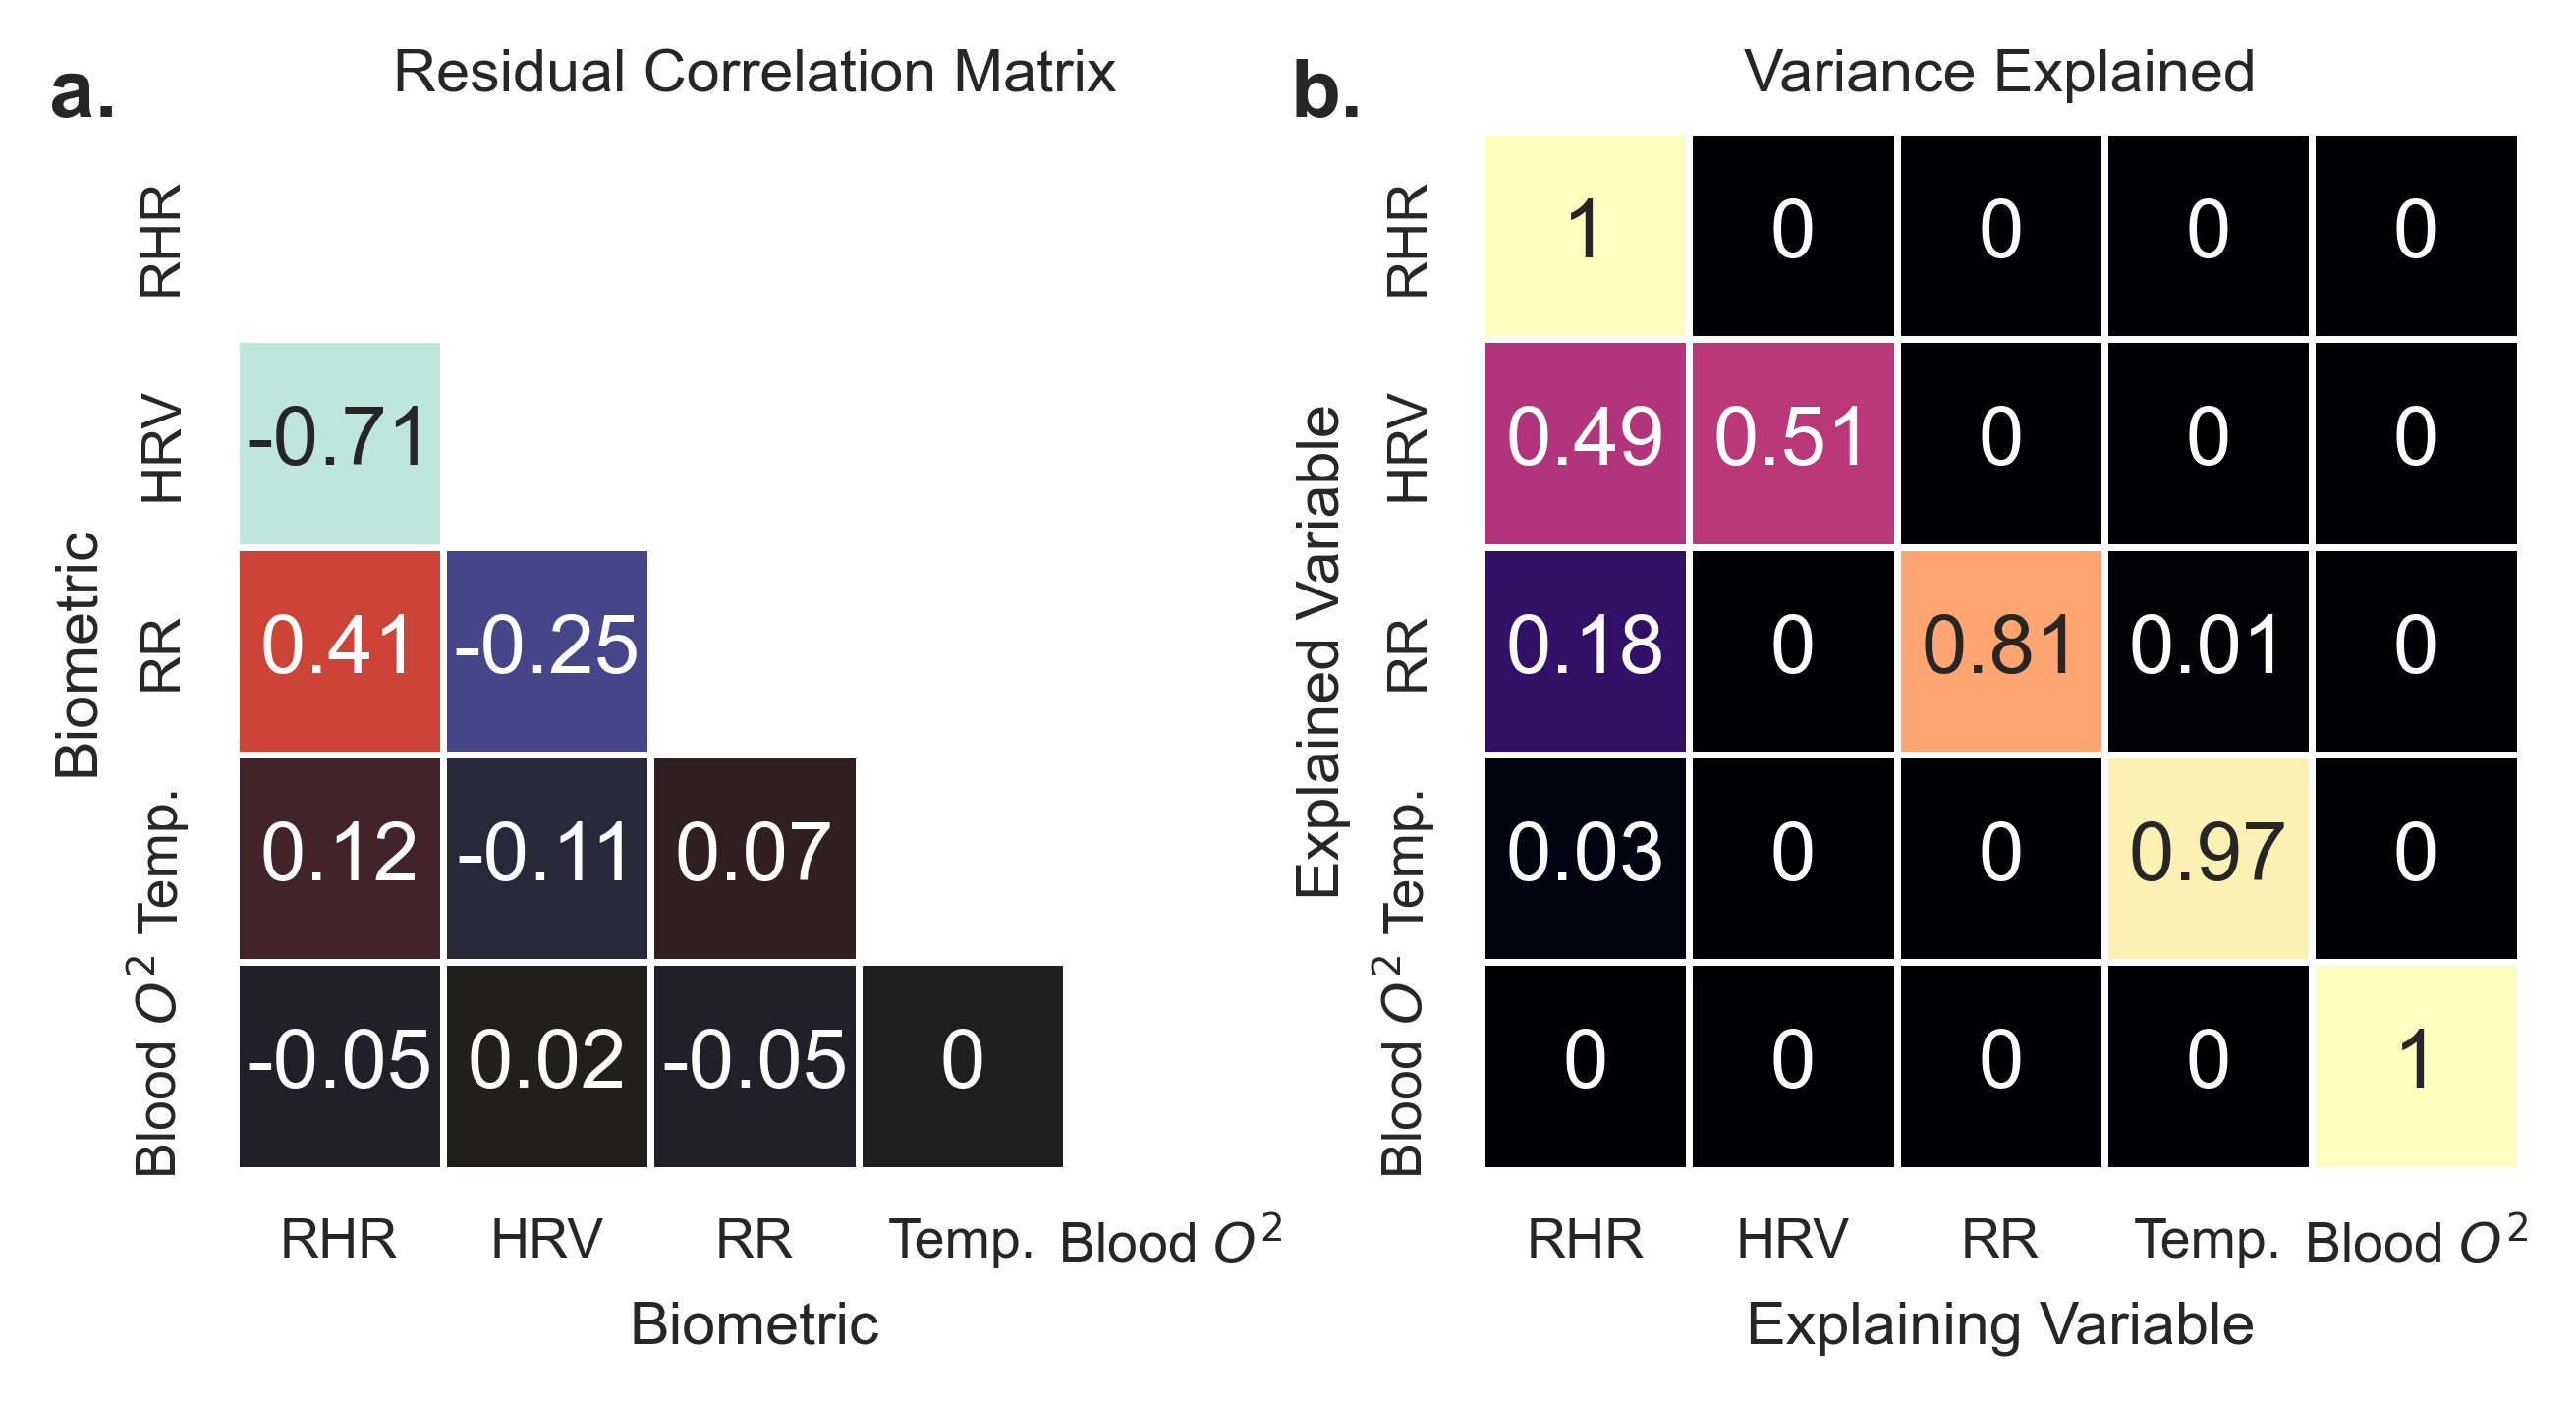

In [6]:
f, axes = BV.plot_model_res_matrices()
plt.show()